In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# init spark
spark = SparkSession.builder \
    .appName("IE212_EDA") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# new path for 27 stores
parquet_path = "/kaggle/working/train_filtered_27_stores.parquet"

# if not exists, extract, read raw CSV, filter, and save to parquet
if not os.path.exists(parquet_path):
    print("Parquet not found. Extracting and processing raw CSV...")
    if not os.path.exists("/kaggle/working/train.csv"):
        !7z x /kaggle/input/competitions/favorita-grocery-sales-forecasting/train.csv.7z -o/kaggle/working/ -y
    
    # load raw data
    df_raw = spark.read.csv("/kaggle/working/train.csv", header=True, inferSchema=True)
    
    # early filtering: keep 1 year + 27 stores
    valid_stores = [i for i in range(1, 28)]
    df_filtered = df_raw.filter(
        (col("date") >= "2016-08-01") & 
        (col("date") <= "2017-08-15") &
        (col("store_nbr").isin(valid_stores)) 
    )
    
    # execute and save to parquet
    df_filtered.write.mode("overwrite").parquet(parquet_path)
    print("Saved to Parquet for future runs!")

# CRITICAL FIX: Cut the lineage
print("Loading filtered data from Parquet...")
df_train = spark.read.parquet(parquet_path)

# cache to ram for faster joins later
df_train.cache()

# check rows 
print(f"Total rows: {df_train.count()}")
df_train.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/31 03:52:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Parquet not found. Extracting and processing raw CSV...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /kaggle/input/competitions/favorita-grocery-sales-forecasting/                                                                        1 file, 474092593 bytes (453 MiB)

Extracting archive: /kaggle/input/competitions/favorita-grocery-sales-forecasting/train.csv.7z
--
Path = /kaggle/input/competitions/favorita-grocery-sales-forecasting/train.csv.7z
Type = 7z
Physical Size = 474092593
Headers Size = 122
Method = LZMA2:24
Solid = -
Blocks = 1

  0%      0% - train.csv                  1% - train.csv   

Saved to Parquet for future runs!
Loading filtered data from Parquet...


Total rows: 18819628
root
 |-- id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- store_nbr: integer (nullable = true)
 |-- item_nbr: integer (nullable = true)
 |-- unit_sales: double (nullable = true)
 |-- onpromotion: boolean (nullable = true)



In [2]:
from pyspark.sql.functions import col, count, when, isnan
exprs = []
for c, t in df_train.dtypes:
    if t in ('double', 'float'):
        exprs.append(count(when(isnan(col(c)) | col(c).isNull(), c)).alias(c))
    else:
        exprs.append(count(when(col(c).isNull(), c)).alias(c))
#count missing values
print("Missing Values in Train:")
df_train.select(exprs).show()

# check unique values in categorical column
print("Categorical distribution (onpromotion):")
df_train.groupBy("onpromotion").count().show()

Missing Values in Train:


+---+----+---------+--------+----------+-----------+
| id|date|store_nbr|item_nbr|unit_sales|onpromotion|
+---+----+---------+--------+----------+-----------+
|  0|   0|        0|       0|         0|          0|
+---+----+---------+--------+----------+-----------+

Categorical distribution (onpromotion):


+-----------+--------+
|onpromotion|   count|
+-----------+--------+
|       true| 2258347|
|      false|16561281|
+-----------+--------+



In [3]:
# Stats basics
print("Stats unit_sales:")
df_train.select("unit_sales").summary("count", "mean", "stddev", "min", "max").show()

# negative sale
negative_sales = df_train.filter(col("unit_sales") < 0).count()
print(f"Negative sales: {negative_sales}")

Stats unit_sales:
+-------+------------------+
|summary|        unit_sales|
+-------+------------------+
|  count|          18819628|
|   mean|7.1625042256946605|
| stddev|18.521146888036412|
|    min|           -1943.0|
|    max|           14483.0|
+-------+------------------+

Negative sales: 1419


In [4]:
import os

# extract files if not exist
aux_files = ['oil.csv.7z', 'holidays_events.csv.7z', 'items.csv.7z', 'stores.csv.7z']
for f in aux_files:
    csv_name = f.replace('.7z', '')
    if not os.path.exists(f"/kaggle/working/{csv_name}"):
        print(f"Extracting {f}...")
        os.system(f"7z x /kaggle/input/competitions/favorita-grocery-sales-forecasting/{f} -o/kaggle/working/ -y")

# load macro data
df_oil = spark.read.csv("/kaggle/working/oil.csv", header=True, inferSchema=True)
df_hol = spark.read.csv("/kaggle/working/holidays_events.csv", header=True, inferSchema=True)

# check missing values in oil 
print("Missing values in Oil:")
df_oil.select([count(when(col(c).isNull(), c)).alias(c) for c in df_oil.columns]).show()

# check holiday types & transferred flags
print("Holiday types distribution:")
df_hol.groupBy("type", "transferred").count().show()

Extracting oil.csv.7z...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 3762 bytes (4 KiB)

Extracting archive: /kaggle/input/competitions/favorita-grocery-sales-forecasting/oil.csv.7z
--
Path = /kaggle/input/competitions/favorita-grocery-sales-forecasting/oil.csv.7z
Type = 7z
Physical Size = 3762
Headers Size = 122
Method = LZMA2:24k
Solid = -
Blocks = 1

Everything is Ok

Size:       20580
Compressed: 3762
Extracting holidays_events.csv.7z...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 1898 bytes (2 KiB)

Extracting archive: /kaggle/input/competitions/favorita-grocery-sales-forecasting/holidays_events.cs

In [5]:
from pyspark.sql.window import Window
from pyspark.sql.functions import last, first, to_date

# --- 1. PROCESS OIL  ---
df_oil = spark.read.csv("/kaggle/working/oil.csv", header=True, inferSchema=True)
df_oil = df_oil.withColumn("date", to_date(col("date")))

# TDense Calendar from Train 
df_dates = df_train.select("date").distinct()
df_oil_dense = df_dates.join(df_oil, "date", "left")

# ffill n bfill 
window_ffill = Window.orderBy("date").rowsBetween(Window.unboundedPreceding, 0)
window_bfill = Window.orderBy("date").rowsBetween(0, Window.unboundedFollowing)

df_oil_dense = df_oil_dense.withColumn("dcoilwtico", last("dcoilwtico", ignorenulls=True).over(window_ffill))
df_oil_dense = df_oil_dense.withColumn("dcoilwtico", first("dcoilwtico", ignorenulls=True).over(window_bfill))

# --- 2. PROCESS HOLIDAYS  ---
df_hol = spark.read.csv("/kaggle/working/holidays_events.csv", header=True, inferSchema=True)
df_hol = df_hol.withColumn("date", to_date(col("date")))
df_hol = df_hol.filter(col("transferred") == False)

# Drop duplicate
df_hol = df_hol.dropDuplicates(["date"])

df_hol = df_hol.withColumnRenamed("type", "holiday_type")
df_hol = df_hol.select("date", "holiday_type", "locale")

print("Oil and Holidays processed.")

Oil and Holidays processed.


In [ ]:
from pyspark.sql.functions import broadcast, when, col

df_items = spark.read.csv("/kaggle/working/items.csv", header=True, inferSchema=True)
df_stores = spark.read.csv("/kaggle/working/stores.csv", header=True, inferSchema=True)

# CRITICAL FIX
df_train_clipped = df_train.withColumn("unit_sales", when(col("unit_sales") < 0, 0.0).otherwise(col("unit_sales")))

# Join data 
df_base = df_train_clipped.join(broadcast(df_stores), "store_nbr", "left") \
                  .join(broadcast(df_items), "item_nbr", "left") \
                  .join(broadcast(df_oil_dense), "date", "left") \
                  .join(broadcast(df_hol), "date", "left")

# Fill null for normal day
df_base = df_base.fillna({"holiday_type": "Normal", "locale": "National"})

print(f"Total rows after joins: {df_base.count()}")
print("Check nulls :")
df_base.select([count(when(col(c).isNull(), c)).alias(c) for c in ["dcoilwtico", "holiday_type"]]).show()

Total rows after joins: 18819628
Check nulls :


+----------+------------+
|dcoilwtico|holiday_type|
+----------+------------+
|         0|           0|
+----------+------------+



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 8.0 MB/s eta 0:00:00


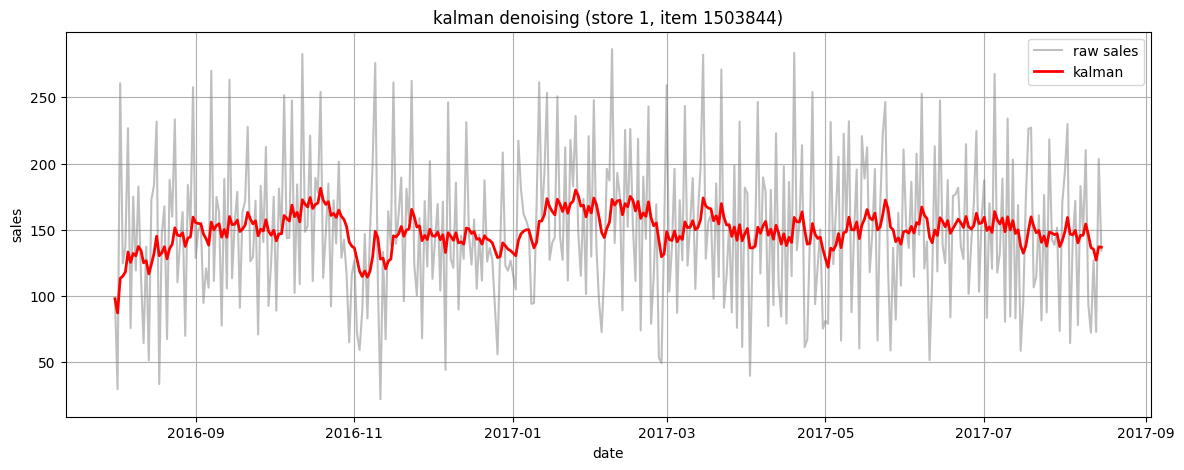

In [7]:
!pip install pykalman -q

import pandas as pd
import matplotlib.pyplot as plt
from pykalman import KalmanFilter
from pyspark.sql.functions import col

# enable arrow for faster pandas udf
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
spark.conf.set("spark.sql.execution.arrow.maxRecordsPerBatch", "10000")

# build safe ddl schema
schema_ddl = ", ".join([f"{f.name} {f.dataType.simpleString()}" for f in df_base.schema.fields]) + ", kalman_sales float"

def apply_kalman_grouped(pdf: pd.DataFrame) -> pd.DataFrame:
    pdf = pdf.sort_values("date")
    if len(pdf) < 2:
        pdf["kalman_sales"] = pdf["unit_sales"]
        return pdf
        
    kf = KalmanFilter(transition_matrices=[1], observation_matrices=[1],
                      initial_state_mean=pdf["unit_sales"].iloc[0], initial_state_covariance=1,
                      observation_covariance=5, transition_covariance=0.1)
    
    state_means, _ = kf.filter(pdf["unit_sales"].values)
    pdf["kalman_sales"] = state_means.flatten()
    return pdf

# apply udf with repartition
df_kalman = df_base.repartition(200, "store_nbr", "item_nbr") \
    .groupBy("store_nbr", "item_nbr") \
    .applyInPandas(apply_kalman_grouped, schema=schema_ddl)

# new path for 27 stores version
output_path = "/kaggle/working/base_processed_27_stores.parquet"
df_kalman.write.mode("overwrite").parquet(output_path)

# check plot
df_check = spark.read.parquet(output_path)
pdf_sample = df_check.filter((col("store_nbr") == 1) & (col("item_nbr") == 1503844)).orderBy("date").toPandas()

if not pdf_sample.empty:
    plt.figure(figsize=(14, 5))
    plt.plot(pdf_sample['date'], pdf_sample['unit_sales'], label='raw sales', alpha=0.5, color='gray')
    plt.plot(pdf_sample['date'], pdf_sample['kalman_sales'], label='kalman', color='red', linewidth=2)
    plt.title('kalman denoising (store 1, item 1503844)')
    plt.xlabel('date')
    plt.ylabel('sales')
    plt.legend()
    plt.grid(True)
    # save plot with new name
    plt.savefig("/kaggle/working/kalman_report_27_stores.png", dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
!pip install PyWavelets -q

import pandas as pd
import pywt
import numpy as np
from pyspark.sql.functions import col
import warnings

# read from the new kalman parquet (27 stores)
df_base = spark.read.parquet("/kaggle/working/base_processed_27_stores.parquet")

# build safe ddl schema for wavelet
schema_wavelet = ", ".join([f"{f.name} {f.dataType.simpleString()}" for f in df_base.schema.fields]) + ", wavelet_soft_sales float, wavelet_hard_sales float"

def apply_wavelet_grouped(pdf: pd.DataFrame) -> pd.DataFrame:
    warnings.filterwarnings("ignore", category=UserWarning, module="pywt")
    pdf = pdf.sort_values("date")
    if len(pdf) < 2:
        pdf["wavelet_soft_sales"] = pdf["unit_sales"]
        pdf["wavelet_hard_sales"] = pdf["unit_sales"]
        return pdf
        
    signal = pdf["unit_sales"].values
    wavelet = 'db4'
    level = 2
    # check length for wavelet level
    if len(signal) < 2**level:
        level = 1
        if len(signal) < 2: level = 0
    
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    
    coeffs_soft = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs]
    reconstructed_soft = pywt.waverec(coeffs_soft, wavelet)
    
    coeffs_hard = [pywt.threshold(c, value=uthresh, mode='hard') for c in coeffs]
    reconstructed_hard = pywt.waverec(coeffs_hard, wavelet)
    
    pdf["wavelet_soft_sales"] = reconstructed_soft[:len(signal)]
    pdf["wavelet_hard_sales"] = reconstructed_hard[:len(signal)]
    
    return pdf

df_wavelet = df_base.repartition(200, "store_nbr", "item_nbr") \
    .groupBy("store_nbr", "item_nbr") \
    .applyInPandas(apply_wavelet_grouped, schema=schema_wavelet)

# new path for wavelet output
out_wavelet = "/kaggle/working/features_wavelet_27_stores.parquet"
df_wavelet.write.mode("overwrite").parquet(out_wavelet)

In [9]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, mean, stddev, coalesce, lit, datediff

df_features = spark.read.parquet("/kaggle/working/features_wavelet_27_stores.parquet")

# create time_idx for TFT model (Track 3)
df_features = df_features.withColumn("time_idx", datediff(col("date"), lit("2016-08-01")))

window_ts = Window.partitionBy("store_nbr", "item_nbr").orderBy("date")

# generate lags for all signal variations (raw, kalman, wavelet)
target_cols = ["unit_sales", "kalman_sales", "wavelet_soft_sales"]
for t_col in target_cols:
    df_features = df_features.withColumn(f"lag_1_{t_col}", lag(t_col, 1).over(window_ts))
    df_features = df_features.withColumn(f"lag_7_{t_col}", lag(t_col, 7).over(window_ts))
    df_features = df_features.withColumn(f"lag_16_{t_col}", lag(t_col, 16).over(window_ts))

window_roll_7 = window_ts.rowsBetween(-7, -1)
window_roll_30 = window_ts.rowsBetween(-30, -1)

# rolling features on raw sales (baseline)
df_features = df_features.withColumn("rolling_mean_7", mean("unit_sales").over(window_roll_7))
df_features = df_features.withColumn("rolling_std_7", coalesce(stddev("unit_sales").over(window_roll_7), lit(0.0)))
df_features = df_features.withColumn("rolling_mean_30", mean("unit_sales").over(window_roll_30))

out_master = "/kaggle/working/engineered_features_27_stores.parquet"
df_features.write.mode("overwrite").parquet(out_master)

In [10]:
from pyspark.ml.feature import StringIndexer

# read from the 27 stores master data
df_features = spark.read.parquet("/kaggle/working/engineered_features_27_stores.parquet")

# string indexer for categorical columns
cat_cols = ["city", "state", "type", "cluster", "family", "class", "holiday_type", "locale"]
out_cols = [c + "_idx" for c in cat_cols]
indexer = StringIndexer(inputCols=cat_cols, outputCols=out_cols, handleInvalid="keep")
df_features = indexer.fit(df_features).transform(df_features)

# drop strings to save ram
df_features = df_features.drop(*cat_cols)

# new path for final encoded data (27 stores)
out_final = "/kaggle/working/engineered_features_encoded_27_stores.parquet"
df_features.repartition(200, "store_nbr", "item_nbr").write.mode("overwrite").parquet(out_final)
print(f"saved final encoded data to {out_final}")

# check final schema
df_features.printSchema()

saved final encoded data to /kaggle/working/engineered_features_encoded_27_stores.parquet
root
 |-- date: date (nullable = true)
 |-- item_nbr: integer (nullable = true)
 |-- store_nbr: integer (nullable = true)
 |-- id: integer (nullable = true)
 |-- unit_sales: double (nullable = true)
 |-- onpromotion: boolean (nullable = true)
 |-- perishable: integer (nullable = true)
 |-- dcoilwtico: double (nullable = true)
 |-- kalman_sales: float (nullable = true)
 |-- wavelet_soft_sales: float (nullable = true)
 |-- wavelet_hard_sales: float (nullable = true)
 |-- time_idx: integer (nullable = true)
 |-- lag_1_unit_sales: double (nullable = true)
 |-- lag_7_unit_sales: double (nullable = true)
 |-- lag_16_unit_sales: double (nullable = true)
 |-- lag_1_kalman_sales: float (nullable = true)
 |-- lag_7_kalman_sales: float (nullable = true)
 |-- lag_16_kalman_sales: float (nullable = true)
 |-- lag_1_wavelet_soft_sales: float (nullable = true)
 |-- lag_7_wavelet_soft_sales: float (nullable = tru

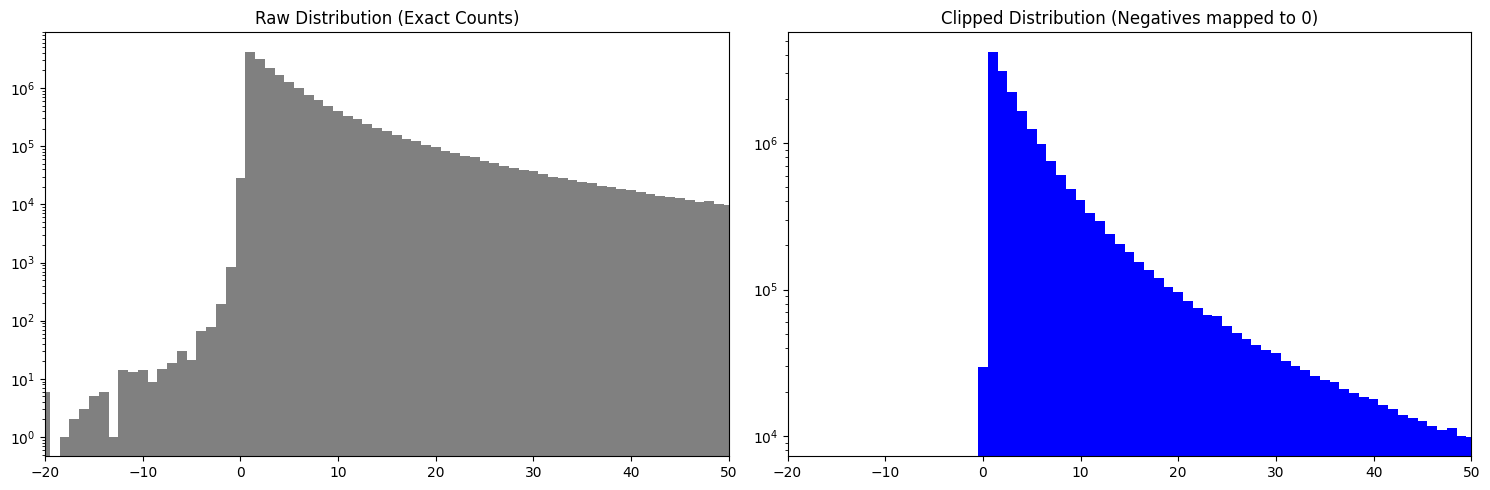

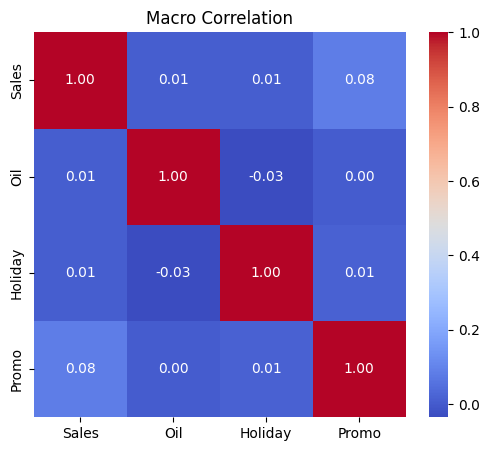

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, round, when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# read raw data from 27 stores version
df_raw = spark.read.parquet("/kaggle/working/train_filtered_27_stores.parquet")

# clip negatives to 0 on spark
df_clipped = df_raw.withColumn("clipped_sales", when(col("unit_sales") < 0, 0).otherwise(col("unit_sales")))

# create int bins for plotting
df_bins_raw = df_raw.withColumn("bin", round(col("unit_sales"), 0))
df_bins_clipped = df_clipped.withColumn("bin", round(col("clipped_sales"), 0))

# filter range and aggregate exact counts (very safe for RAM)
pdf_raw_counts = df_bins_raw.filter(col("bin").between(-20, 50)) \
                            .groupBy("bin").count().orderBy("bin").toPandas()

pdf_clipped_counts = df_bins_clipped.filter(col("bin").between(-20, 50)) \
                                    .groupBy("bin").count().orderBy("bin").toPandas()

# plot 1: dist comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(pdf_raw_counts['bin'], pdf_raw_counts['count'], color='gray', width=1.0)
axes[0].set_title('Raw Distribution (Exact Counts)')
axes[0].set_xlim(-20, 50)
axes[0].set_yscale('log') 

axes[1].bar(pdf_clipped_counts['bin'], pdf_clipped_counts['count'], color='blue', width=1.0)
axes[1].set_title('Clipped Distribution (Negatives mapped to 0)')
axes[1].set_xlim(-20, 50)
axes[1].set_yscale('log')

plt.tight_layout()
# save plot with new name
plt.savefig("/kaggle/working/sales_distribution_exact_27_stores.png", dpi=300)
plt.show()

# load processed data for macro corr (27 stores)
df_base = spark.read.parquet("/kaggle/working/base_processed_27_stores.parquet")

# create binary hol flag and drop nulls
df_corr = df_base.withColumn("is_hol", when(col("holiday_type") != "Normal", 1).otherwise(0))
df_corr = df_corr.na.drop(subset=["unit_sales", "dcoilwtico", "is_hol", "onpromotion"])

# vector assemble
assembler = VectorAssembler(inputCols=["unit_sales", "dcoilwtico", "is_hol", "onpromotion"], outputCol="features")
df_vec = assembler.transform(df_corr).select("features")

# compute pearson matrix
corr_mat = Correlation.corr(df_vec, "features", "pearson").collect()[0][0].toArray()

# plot 2: heatmap
plt.figure(figsize=(6, 5))
cols = ["Sales", "Oil", "Holiday", "Promo"]
sns.heatmap(corr_mat, annot=True, xticklabels=cols, yticklabels=cols, cmap='coolwarm', fmt=".2f")
plt.title("Macro Correlation")
# save plot with new name
plt.savefig("/kaggle/working/macro_corr_27_stores.png", bbox_inches='tight')
plt.show()

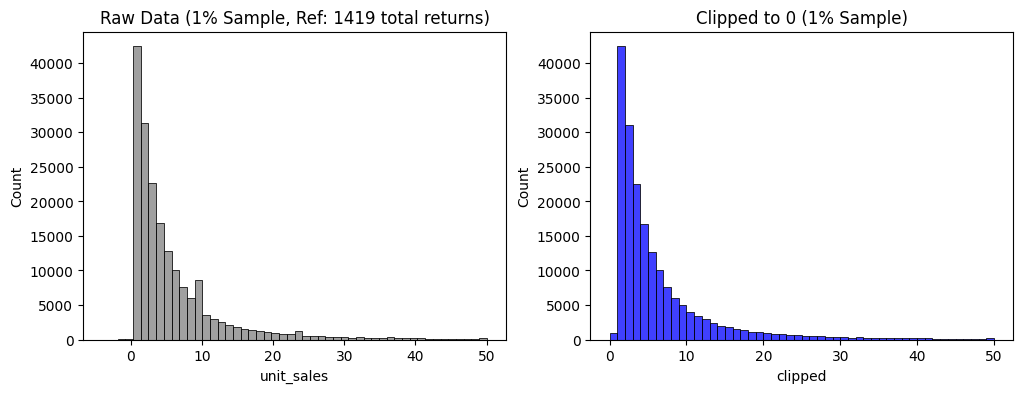

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col

# read from 27 stores version
df_raw = spark.read.parquet("/kaggle/working/train_filtered_27_stores.parquet")

# count total negative returns for reference
n_neg = df_raw.filter(col("unit_sales") < 0).count()

# sample 1% of data in range [-20, 50] to avoid OOM in pandas
pdf_dist = df_raw.filter(col("unit_sales").between(-20, 50)) \
                 .sample(fraction=0.01, seed=42) \
                 .select("unit_sales").toPandas()

# clip negatives to 0
pdf_dist['clipped'] = pdf_dist['unit_sales'].clip(lower=0)

# plot dist comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(pdf_dist['unit_sales'], bins=50, ax=ax[0], color='gray')
ax[0].set_title(f'Raw Data (1% Sample, Ref: {n_neg} total returns)')

sns.histplot(pdf_dist['clipped'], bins=50, ax=ax[1], color='blue')
ax[1].set_title('Clipped to 0 (1% Sample)')

# save plot with new name for 27 stores
plt.savefig("/kaggle/working/sales_dist_sample_1pct_27_stores.png", bbox_inches='tight')
plt.show()

Finding a top-selling item to plot signals...


Top selling item found: Store 3, Item 1503844


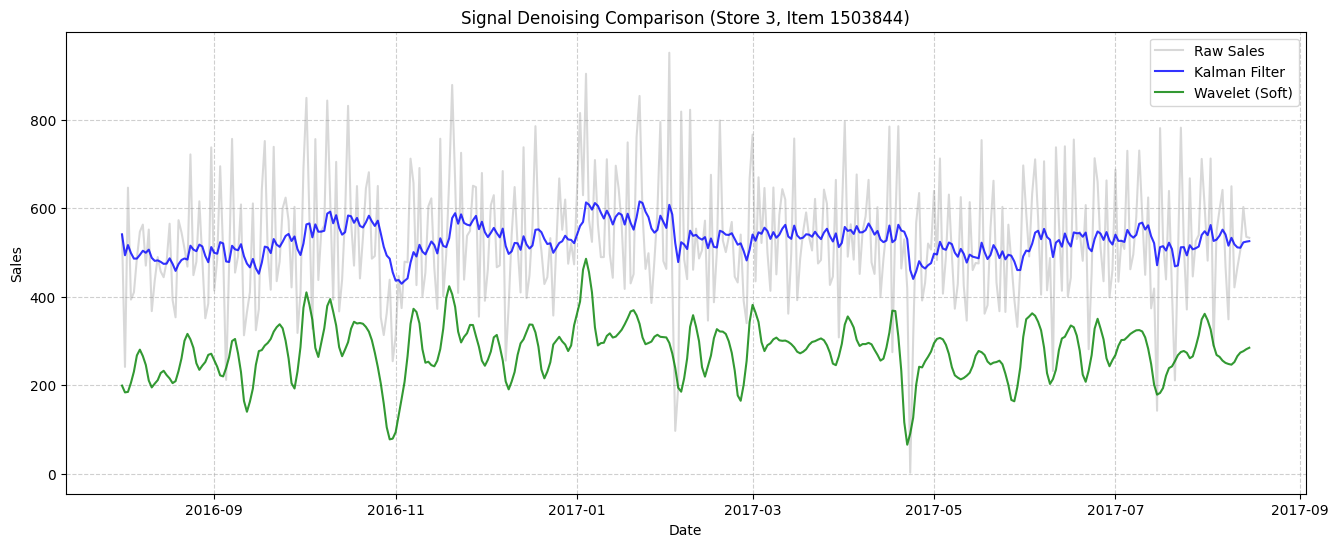

Saved plot to signal_denoising_comparison_27_stores.png


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col, sum

print("Finding a top-selling item to plot signals...")

# read from 27 stores master features
df_plot = spark.read.parquet("/kaggle/working/engineered_features_27_stores.parquet")

# auto-find top item to ensure dense data for plotting
top_item = df_plot.groupBy("store_nbr", "item_nbr") \
                  .agg(sum("unit_sales").alias("total_sales")) \
                  .orderBy(col("total_sales").desc()) \
                  .first()

best_store = top_item["store_nbr"]
best_item = top_item["item_nbr"]
print(f"Top selling item found: Store {best_store}, Item {best_item}")

# extract data to pandas
pdf_sample = df_plot.filter((col("store_nbr") == best_store) & (col("item_nbr") == best_item)) \
                    .select("date", "unit_sales", "kalman_sales", "wavelet_soft_sales") \
                    .orderBy("date").toPandas()

# plot all signals
plt.figure(figsize=(16, 6))
plt.plot(pdf_sample['date'], pdf_sample['unit_sales'], label='Raw Sales', alpha=0.3, color='gray')
plt.plot(pdf_sample['date'], pdf_sample['kalman_sales'], label='Kalman Filter', alpha=0.8, color='blue', linewidth=1.5)
plt.plot(pdf_sample['date'], pdf_sample['wavelet_soft_sales'], label='Wavelet (Soft)', alpha=0.8, color='green', linewidth=1.5)

plt.title(f'Signal Denoising Comparison (Store {best_store}, Item {best_item})')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# save plot with new name
plt.savefig("/kaggle/working/signal_denoising_comparison_27_stores.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved plot to signal_denoising_comparison_27_stores.png")

Dynamically finding the best store and item...


-> Selected for plotting: Store 3, Item 1503844


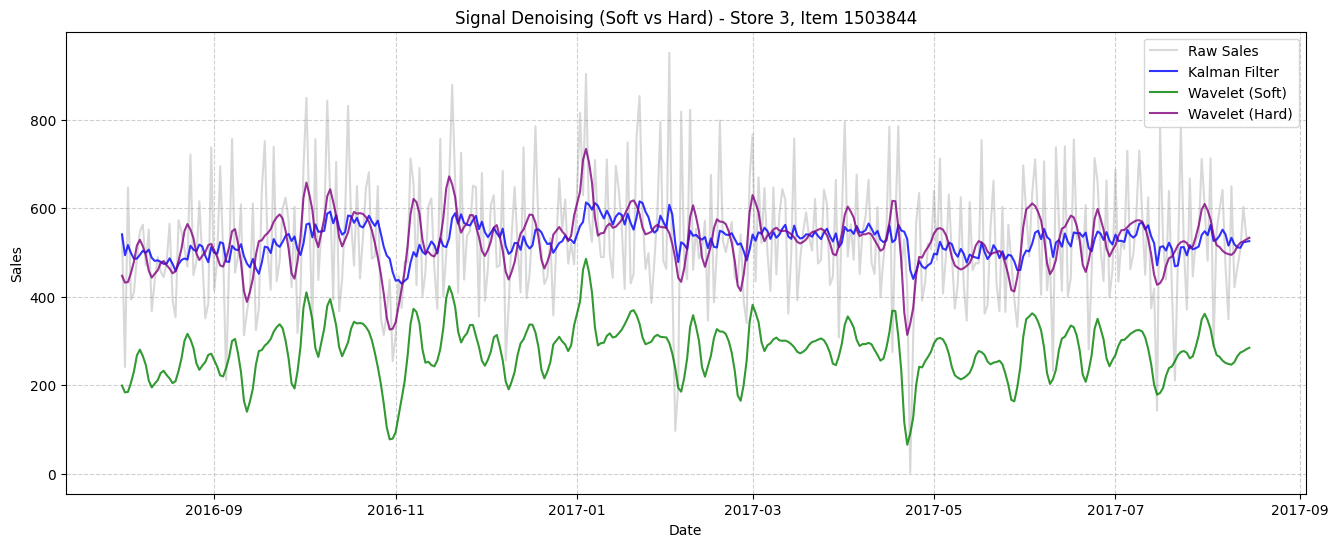

Saved plot to signal_denoising_with_hard_27_stores.png


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col, sum

# read from 27 stores master features
df_plot = spark.read.parquet("/kaggle/working/engineered_features_27_stores.parquet")

print("Dynamically finding the best store and item...")

# auto-find top item to avoid hardcoding and missing data
top_item = df_plot.groupBy("store_nbr", "item_nbr") \
                  .agg(sum("unit_sales").alias("total_sales")) \
                  .orderBy(col("total_sales").desc()) \
                  .first()

best_store = top_item["store_nbr"]
best_item = top_item["item_nbr"]
print(f"-> Selected for plotting: Store {best_store}, Item {best_item}")

# extract sample
pdf_sample = df_plot.filter((col("store_nbr") == best_store) & (col("item_nbr") == best_item)) \
                    .select("date", "unit_sales", "kalman_sales", "wavelet_soft_sales", "wavelet_hard_sales") \
                    .orderBy("date").toPandas()

# plot all 4 signals
plt.figure(figsize=(16, 6))
plt.plot(pdf_sample['date'], pdf_sample['unit_sales'], label='Raw Sales', alpha=0.3, color='gray')
plt.plot(pdf_sample['date'], pdf_sample['kalman_sales'], label='Kalman Filter', alpha=0.8, color='blue', linewidth=1.5)
plt.plot(pdf_sample['date'], pdf_sample['wavelet_soft_sales'], label='Wavelet (Soft)', alpha=0.8, color='green', linewidth=1.5)
plt.plot(pdf_sample['date'], pdf_sample['wavelet_hard_sales'], label='Wavelet (Hard)', alpha=0.8, color='purple', linewidth=1.5)

plt.title(f'Signal Denoising (Soft vs Hard) - Store {best_store}, Item {best_item}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# save plot with new name
plt.savefig("/kaggle/working/signal_denoising_with_hard_27_stores.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved plot to signal_denoising_with_hard_27_stores.png")

In [16]:
# load final encoded dataset
df_final = spark.read.parquet("/kaggle/working/engineered_features_encoded_27_stores.parquet")

# check dataset dimensions
num_rows = df_final.count()
num_cols = len(df_final.columns)
print(f"Validation Result - Rows: {num_rows}, Columns: {num_cols}")

# verify zero string columns remain in schema
string_features = [f.name for f in df_final.schema.fields if f.dataType.simpleString() == "string"]
print(f"Verification - String columns remaining: {len(string_features)}")
# trigger strict type assertion
assert len(string_features) == 0, "QA Failed: String columns detected!"
assert num_cols == 32, f"QA Failed: Expected 32 columns, got {num_cols}"
print("QA Status: PASSED. Dataset is ready for model input.")

# print full final schema for report documentation
df_final.printSchema()

Validation Result - Rows: 18819628, Columns: 32
Verification - String columns remaining: 0
QA Status: PASSED. Dataset is ready for model input.
root
 |-- date: date (nullable = true)
 |-- item_nbr: integer (nullable = true)
 |-- store_nbr: integer (nullable = true)
 |-- id: integer (nullable = true)
 |-- unit_sales: double (nullable = true)
 |-- onpromotion: boolean (nullable = true)
 |-- perishable: integer (nullable = true)
 |-- dcoilwtico: double (nullable = true)
 |-- kalman_sales: float (nullable = true)
 |-- wavelet_soft_sales: float (nullable = true)
 |-- wavelet_hard_sales: float (nullable = true)
 |-- time_idx: integer (nullable = true)
 |-- lag_1_unit_sales: double (nullable = true)
 |-- lag_7_unit_sales: double (nullable = true)
 |-- lag_16_unit_sales: double (nullable = true)
 |-- lag_1_kalman_sales: float (nullable = true)
 |-- lag_7_kalman_sales: float (nullable = true)
 |-- lag_16_kalman_sales: float (nullable = true)
 |-- lag_1_wavelet_soft_sales: float (nullable = true

In [17]:
import os

cmd = "zip -rq /kaggle/working/output.zip /kaggle/working/engineered_features_encoded_27_stores.parquet"
os.system(cmd)

print("Compression completed successfully.")

Compression completed successfully.
